<a href="https://colab.research.google.com/github/PabloShol/simulacion2/blob/main/Caminata_sobre_un_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminata aleatoria sobre un grafo: secuencias binarias sin 1s adyacentes

**Objetivo.** Simular la cadena de Markov del ejemplo y verificar numéricamente que su distribución estacionaria es **uniforme** sobre las secuencias "buenas".

**Regla de la caminata** (desde una secuencia buena de longitud $m$):
1. Elegir una posición $k \in \{1,\dots,m\}$ con probabilidad $1/m$.
2. Si el bit es 1 → cambiarlo a 0 (siempre queda buena) y moverse.
3. Si el bit es 0 → cambiarlo a 1 **solo si** la secuencia sigue siendo buena; si no, **quedarse** (lazo).

**Por qué es uniforme:** cada vértice tiene peso total $m$ (aristas de peso 1 + lazo). En una caminata sobre grafo ponderado $\pi_i \propto w(i)$, así que todos los estados tienen la misma probabilidad. Equivalentemente, $P$ es **simétrica** ($P_{ij}=P_{ji}=1/m$), por lo que $\pi_i=\text{cte}$ cumple balance detallado.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product

rng = np.random.default_rng(42)



In [3]:
def es_buena(s):
    # True si la secuencia (tupla de 0/1) no tiene dos 1s adyacentes
    return all(not (s[i] == 1 and s[i+1] == 1) for i in range(len(s) - 1))

def secuencias_buenas(m):
    return [s for s in product([0, 1], repeat=m) if es_buena(s)]

def a_str(s):
    return "".join(map(str, s))

m = 4
estados = secuencias_buenas(m)
idx = {s: i for i, s in enumerate(estados)}
print(f"m = {m}: {len(estados)} secuencias buenas")
print([a_str(s) for s in estados])

# Comprobación de Fibonacci
for mm in range(1, 11):
    print(mm, len(secuencias_buenas(mm)), end=" | ")

m = 4: 8 secuencias buenas
['0000', '0001', '0010', '0100', '0101', '1000', '1001', '1010']
1 2 | 2 3 | 3 5 | 4 8 | 5 13 | 6 21 | 7 34 | 8 55 | 9 89 | 10 144 | 

In [4]:
def paso(s, k):
    # Aplica la regla de la caminata a la posición k; devuelve el nuevo estado
    t = list(s)
    t[k] = 1 - t[k]
    t = tuple(t)
    return t if es_buena(t) else s   # si queda mala, se queda en s

def matriz_transicion(m):
    est = secuencias_buenas(m)
    ix = {s: i for i, s in enumerate(est)}
    n = len(est)
    P = np.zeros((n, n))
    for s in est:
        for k in range(m):
            P[ix[s], ix[paso(s, k)]] += 1 / m
    return P, est

P, estados = matriz_transicion(m)
np.set_printoptions(precision=2, suppress=True)
print("Etiquetas:", [a_str(s) for s in estados])
print(P)
print("\n¿Filas suman 1?   ", np.allclose(P.sum(axis=1), 1))
print("¿P es simétrica?  ", np.allclose(P, P.T))

Etiquetas: ['0000', '0001', '0010', '0100', '0101', '1000', '1001', '1010']
[[0.   0.25 0.25 0.25 0.   0.25 0.   0.  ]
 [0.25 0.25 0.   0.   0.25 0.   0.25 0.  ]
 [0.25 0.   0.5  0.   0.   0.   0.   0.25]
 [0.25 0.   0.   0.5  0.25 0.   0.   0.  ]
 [0.   0.25 0.   0.25 0.5  0.   0.   0.  ]
 [0.25 0.   0.   0.   0.   0.25 0.25 0.25]
 [0.   0.25 0.   0.   0.   0.25 0.5  0.  ]
 [0.   0.   0.25 0.   0.   0.25 0.   0.5 ]]

¿Filas suman 1?    True
¿P es simétrica?   True


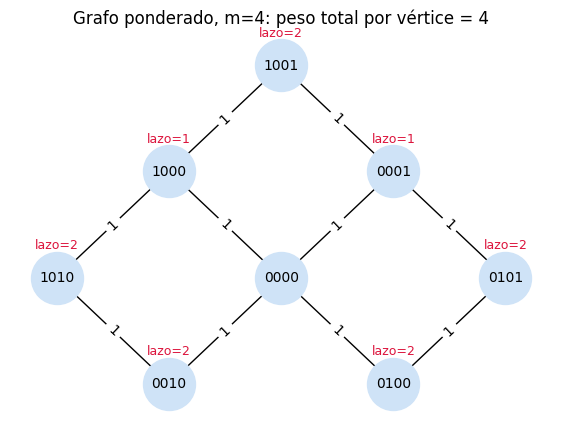

Peso total por vértice: {'0000': 4, '0001': 4, '0010': 4, '0100': 4, '0101': 4, '1000': 4, '1001': 4, '1010': 4}


In [5]:
G = nx.Graph()
for s in estados:
    G.add_node(a_str(s))
for i, s in enumerate(estados):
    for j, t in enumerate(estados):
        if i < j and sum(a != b for a, b in zip(s, t)) == 1:
            G.add_edge(a_str(s), a_str(t), weight=1)

lazo = {a_str(s): m - G.degree(a_str(s)) for s in estados}

# Posiciones parecidas a la figura del libro
pos = {"1001": (0, 3), "1000": (-1, 2), "0001": (1, 2), "1010": (-2, 1),
       "0000": (0, 1), "0101": (2, 1), "0010": (-1, 0), "0100": (1, 0)}

fig, ax = plt.subplots(figsize=(7, 5))
nx.draw_networkx(G, pos, ax=ax, node_color="#cfe3f7", node_size=1400, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), ax=ax)
for v, (x, y) in pos.items():
    if lazo[v] > 0:
        ax.annotate(f"lazo={lazo[v]}", (x, y + 0.28), ha="center", color="crimson", fontsize=9)
ax.set_title(f"Grafo ponderado, m={m}: peso total por vértice = {m}")
ax.axis("off"); plt.show()

print("Peso total por vértice:", {v: G.degree(v) + lazo[v] for v in G.nodes})

In [6]:
vals, vecs = np.linalg.eig(P.T)
k = np.argmin(np.abs(vals - 1))
pi = np.real(vecs[:, k]); pi = pi / pi.sum()

print("π =", np.round(pi, 4))
print("Uniforme 1/|Ω| =", round(1 / len(estados), 4))
print("¿πP = π?", np.allclose(pi @ P, pi))

# Valores propios: |λ|<1 salvo λ=1  ->  cadena regular (ergódica)
print("Valores propios:", np.round(np.sort(np.abs(vals))[::-1], 3))
print("¿P^n > 0 para algún n? (regular):", (np.linalg.matrix_power(P, m) > 0).all())

π = [0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]
Uniforme 1/|Ω| = 0.125
¿πP = π? True
Valores propios: [1.   0.81 0.68 0.44 0.39 0.37 0.14 0.05]
¿P^n > 0 para algún n? (regular): True


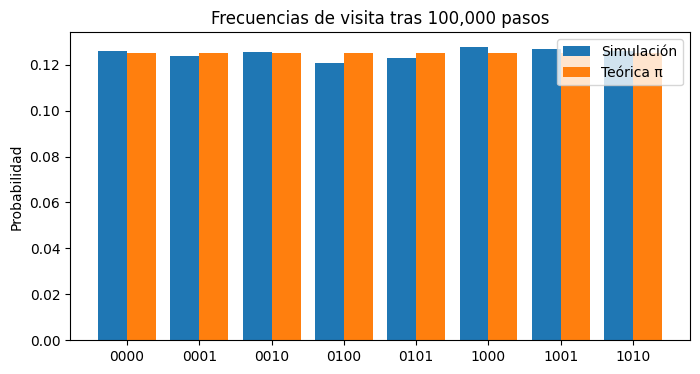

0000: 0.1258  (error 0.0008)
0001: 0.1239  (error 0.0011)
0010: 0.1254  (error 0.0004)
0100: 0.1209  (error 0.0041)
0101: 0.1231  (error 0.0019)
1000: 0.1277  (error 0.0027)
1001: 0.1270  (error 0.0020)
1010: 0.1261  (error 0.0011)


In [7]:
def caminata(m, n_pasos, inicio=None, rng=rng):
    s = tuple([0] * m) if inicio is None else tuple(inicio)
    trayectoria = [s]
    for _ in range(n_pasos):
        k = rng.integers(m)          # posición elegida uniformemente
        s = paso(s, k)
        trayectoria.append(s)
    return trayectoria

n = 100_000
tray = caminata(m, n)
conteo = np.zeros(len(estados))
for s in tray:
    conteo[idx[s]] += 1
freq = conteo / conteo.sum()

etiq = [a_str(s) for s in estados]
x = np.arange(len(etiq))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, freq, 0.4, label="Simulación")
plt.bar(x + 0.2, pi, 0.4, label="Teórica π")
plt.xticks(x, etiq); plt.ylabel("Probabilidad")
plt.title(f"Frecuencias de visita tras {n:,} pasos"); plt.legend(); plt.show()

for e, f in zip(etiq, freq):
    print(f"{e}: {f:.4f}  (error {abs(f - 1/len(estados)):.4f})")

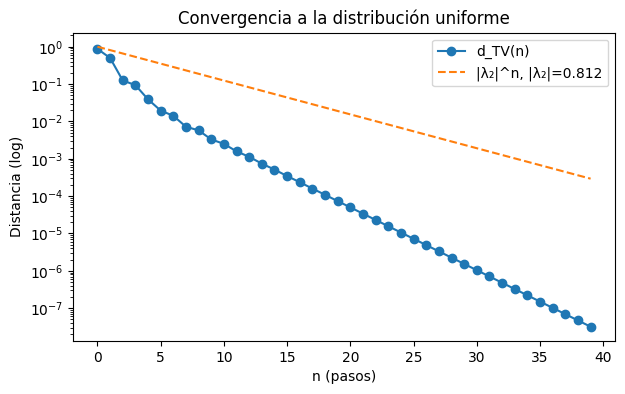

In [8]:
mu = np.zeros(len(estados)); mu[idx[tuple([0]*m)]] = 1   # inicia en 0000
tv = []
for _ in range(40):
    tv.append(0.5 * np.abs(mu - pi).sum())
    mu = mu @ P

lam2 = np.sort(np.abs(vals))[::-1][1]
plt.figure(figsize=(7, 4))
plt.semilogy(tv, "o-", label="d_TV(n)")
plt.semilogy([lam2**k for k in range(40)], "--", label=f"|λ₂|^n, |λ₂|={lam2:.3f}")
plt.xlabel("n (pasos)"); plt.ylabel("Distancia (log)")
plt.title("Convergencia a la distribución uniforme"); plt.legend(); plt.show()

m=10 -> exacto: 2.9167 | MCMC: 2.9263
m=30 -> MCMC: 8.4373 1s en promedio


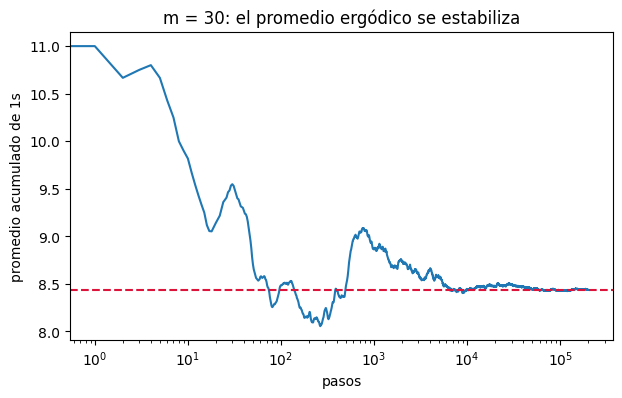

In [9]:
def estimar_unos(m, n_pasos, burn_in=1000):
    tray = caminata(m, n_pasos)[burn_in:]
    unos = np.array([sum(s) for s in tray])
    return unos.mean(), unos

# m pequeño: comparar con el valor exacto
exacto = np.mean([sum(s) for s in secuencias_buenas(10)])
est, _ = estimar_unos(10, 200_000)
print(f"m=10 -> exacto: {exacto:.4f} | MCMC: {est:.4f}")

# m grande: solo simulación
est30, unos30 = estimar_unos(30, 200_000)
print(f"m=30 -> MCMC: {est30:.4f} 1s en promedio")

# Promedio acumulado (teorema ergódico en acción)
prom_acum = np.cumsum(unos30) / np.arange(1, len(unos30) + 1)
plt.figure(figsize=(7, 4))
plt.plot(prom_acum); plt.axhline(est30, color="crimson", ls="--")
plt.xscale("log"); plt.xlabel("pasos"); plt.ylabel("promedio acumulado de 1s")
plt.title("m = 30: el promedio ergódico se estabiliza"); plt.show()